# Phase 3B.4 - Final Acoustic Feature-Based Bayesian Baseline

This notebook fits the final supervisor-aligned Bayesian acoustic-feature mixed-effects baseline for the final 20-stimulus / 5-mix / 3-context design.

It constructs a separate feature-driven synthetic validation dataset. This is distinct from the Phase 3B.1 stimulus-driven synthetic ratings and from future real participant data.

## 1. Imports, Runtime Configuration, and Paths

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import os
import sys
import time
from pathlib import Path

CACHE_ROOT = Path(os.environ.get("TEMP", ".")) / "phase3b4_cache"
(CACHE_ROOT / "pytensor").mkdir(parents=True, exist_ok=True)
(CACHE_ROOT / "numba").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"cxx=,base_compiledir={(CACHE_ROOT / 'pytensor').as_posix()}")
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_ROOT / "numba"))

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

SEED = 44
N_PARTICIPANTS = 40
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 90)
pd.set_option("display.width", 170)
az.rcParams["plot.max_subplots"] = 40

SAMPLING_CONFIG = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.95,
    "random_seed": SEED,
    "inference_method": "nutpie",
}

def package_version(package_name):
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_report = pd.DataFrame([
    {"component": "Python", "version": sys.version.split()[0]},
    {"component": "Bambi", "version": bmb.__version__},
    {"component": "PyMC", "version": pm.__version__},
    {"component": "ArviZ", "version": az.__version__},
    {"component": "NumPy", "version": np.__version__},
    {"component": "pandas", "version": pd.__version__},
    {"component": "matplotlib", "version": metadata.version("matplotlib")},
    {"component": "nutpie", "version": package_version("nutpie")},
])
display(version_report)
display(pd.DataFrame([SAMPLING_CONFIG]))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


,component,version
0,Python,3.13.9
1,Bambi,0.17.2
2,PyMC,5.28.5
3,ArviZ,0.23.4
4,NumPy,2.3.5
5,pandas,2.3.3
6,matplotlib,3.10.6
7,nutpie,0.16.11


,draws,tune,chains,cores,target_accept,random_seed,inference_method
0,1000,1000,4,1,0.95,44,nutpie


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    markers = [
        Path("statistical-baseline/data/synthetic/final_5mix_stimulus_metadata_seed42.csv"),
        Path("statistical-baseline/outputs/feature_exploration/feature_recommendation.json"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()
SYNTHETIC_DIR = REPO_ROOT / "statistical-baseline" / "data" / "synthetic"
FEATURE_EXPLORATION_DIR = REPO_ROOT / "statistical-baseline" / "outputs" / "feature_exploration"
STIMULUS_MODEL_DIR = REPO_ROOT / "statistical-baseline" / "outputs" / "stimulus_model"
OUTPUT_DIR = REPO_ROOT / "statistical-baseline" / "outputs" / "feature_model"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = SYNTHETIC_DIR / "final_5mix_stimulus_metadata_seed42.csv"
FEATURE_RECOMMENDATION_PATH = FEATURE_EXPLORATION_DIR / "feature_recommendation.json"
STIMULUS_MODEL_SUMMARY_PATH = STIMULUS_MODEL_DIR / "execution_summary.csv"
FEATURE_RATINGS_PATH = SYNTHETIC_DIR / "final_5mix_feature_based_ratings_seed44.csv"
GENERATING_PARAMETERS_PATH = SYNTHETIC_DIR / "final_5mix_feature_based_generating_parameters_seed44.json"
TRUE_VARIANCE_ICC_PATH = SYNTHETIC_DIR / "final_5mix_feature_based_true_variance_icc_seed44.csv"

pd.DataFrame([
    {"label": "final_stimulus_metadata", "path": METADATA_PATH.relative_to(REPO_ROOT), "exists": METADATA_PATH.exists()},
    {"label": "feature_recommendation", "path": FEATURE_RECOMMENDATION_PATH.relative_to(REPO_ROOT), "exists": FEATURE_RECOMMENDATION_PATH.exists()},
    {"label": "stimulus_model_summary", "path": STIMULUS_MODEL_SUMMARY_PATH.relative_to(REPO_ROOT), "exists": STIMULUS_MODEL_SUMMARY_PATH.exists()},
    {"label": "feature_model_output_dir", "path": OUTPUT_DIR.relative_to(REPO_ROOT), "exists": OUTPUT_DIR.exists()},
])

,label,path,exists
0,final_stimulus_metadata,statistical-baseline\data\synthetic\final_5mix...,True
1,feature_recommendation,statistical-baseline\outputs\feature_explorati...,True
2,stimulus_model_summary,statistical-baseline\outputs\stimulus_model\ex...,True
3,feature_model_output_dir,statistical-baseline\outputs\feature_model,True


## 2. Load and Validate Final Stimulus Metadata

In [3]:
stimuli = pd.read_csv(METADATA_PATH)
with FEATURE_RECOMMENDATION_PATH.open("r", encoding="utf-8") as handle:
    feature_recommendation = json.load(handle)

EPISODE_LEVELS = ["EDR-1", "EDR-2", "FM-1"]
GROUP_LEVELS = ["group_01", "group_02"]
PRIMARY_FEATURES = ["z_RMS", "z_CF", "z_SW"]
SENSITIVITY_FEATURES = ["z_RMS", "z_CF", "z_SW", "z_SI"]

validation_rows = []
def add_check(check, observed, expected, passed=None):
    if passed is None:
        passed = observed == expected
    validation_rows.append({"check": check, "observed": observed, "expected": expected, "passed": bool(passed)})

add_check("Exactly 20 stimuli", stimuli["stimulus_id"].nunique(), 20)
add_check("Exactly 4 songs", stimuli["song_id"].nunique(), 4)
add_check("Exactly 5 mixes per song", stimuli.groupby("song_id")["mix_id"].nunique().to_dict(), "all songs have 5", (stimuli.groupby("song_id")["mix_id"].nunique() == 5).all())
for col in SENSITIVITY_FEATURES:
    add_check(f"Complete {col}", int(stimuli[col].notna().sum()), 20)
add_check("Complete group/song/stimulus mapping", "complete", "complete", stimuli[["group", "song_id", "mix_id", "stimulus_id"]].notna().all().all())
metadata_validation = pd.DataFrame(validation_rows)
display(metadata_validation)
if not metadata_validation["passed"].all():
    raise AssertionError("Final metadata validation failed.")
display(stimuli[["group", "song_id", "song_title", "mix_id", "stimulus_id", "original_mix_name", *SENSITIVITY_FEATURES]].sort_values(["group", "song_id", "original_mix_name"]))

,check,observed,expected,passed
0,Exactly 20 stimuli,20,20,True
1,Exactly 4 songs,4,4,True
2,Exactly 5 mixes per song,"{'id_like_to_know': 5, 'in_the_meantime': 5, '...",all songs have 5,True
3,Complete z_RMS,20,20,True
4,Complete z_CF,20,20,True
5,Complete z_SW,20,20,True
6,Complete z_SI,20,20,True
7,Complete group/song/stimulus mapping,complete,complete,True


,group,song_id,song_title,mix_id,stimulus_id,original_mix_name,z_RMS,z_CF,z_SW,z_SI
7,group_01,id_like_to_know,I'd Like To Know,mix_9ffcd672af17,id_like_to_know_pxl_s1,PXL-S1,-0.565911,-0.579304,-0.485121,1.357248
8,group_01,id_like_to_know,I'd Like To Know,mix_6f8b655d7999,id_like_to_know_pxl_s2,PXL-S2,0.533000,-1.187467,-0.763752,0.551037
5,group_01,id_like_to_know,I'd Like To Know,mix_65f41f41d3ab,id_like_to_know_pxl_s3,PXL-S3,0.323484,-1.065060,-1.165177,-0.098248
6,group_01,id_like_to_know,I'd Like To Know,mix_82d60d7c7fc5,id_like_to_know_pxl_s5,PXL-S5,-0.358338,-0.152766,0.797271,1.627075
9,group_01,id_like_to_know,I'd Like To Know,mix_b393d3919c78,id_like_to_know_pxl_s7,PXL-S7,-0.867056,-0.618841,-0.322901,-1.051511
0,group_01,lead_me,Lead Me,mix_f1f7973e5bac,lead_me_du_d,DU-D,0.740286,-1.548717,0.328048,-1.017147
1,group_01,lead_me,Lead Me,mix_271852ba8676,lead_me_du_e,DU-E,-1.025058,0.519995,-0.866608,0.995934
4,group_01,lead_me,Lead Me,mix_d3e3580b6e30,lead_me_mcg_pro2,McG-pro2,2.980531,0.859425,-0.926328,0.048774
2,group_01,lead_me,Lead Me,mix_d5b28dfc8a93,lead_me_pxl_l1,PXL-L1,-0.002444,-0.367771,-1.281694,-0.192446
3,group_01,lead_me,Lead Me,mix_c7d9a071ba25,lead_me_pxl_l4,PXL-L4,-0.055201,-0.841212,0.832111,2.390300


## 3. Feature-Driven Synthetic Data-Generating Process

In [4]:
GRAND_MEAN = 66.0
GROUP_EFFECTS = {"group_01": 0.0, "group_02": 1.5}
EPISODE_EFFECTS = {"EDR-1": 2.0, "EDR-2": -1.5, "FM-1": 1.0}
FEATURE_EFFECTS_PRIMARY = {"z_RMS": 2.6, "z_CF": -2.1, "z_SW": 2.3}
FEATURE_EFFECTS_SI_SENSITIVITY_TRUTH = {"z_SI": 0.0}
PARTICIPANT_SD = 8.0
STIMULUS_RESIDUAL_SD = 3.0
RESIDUAL_SD = 9.0
RATING_MIN = 0.0
RATING_MAX = 100.0

participant_variance = PARTICIPANT_SD ** 2
stimulus_residual_variance = STIMULUS_RESIDUAL_SD ** 2
residual_variance = RESIDUAL_SD ** 2
total_random_variance = participant_variance + stimulus_residual_variance + residual_variance
true_variance_icc = pd.DataFrame([
    {"component": "participant", "sd": PARTICIPANT_SD, "variance": participant_variance, "variance_share": participant_variance / total_random_variance},
    {"component": "stimulus_residual", "sd": STIMULUS_RESIDUAL_SD, "variance": stimulus_residual_variance, "variance_share": stimulus_residual_variance / total_random_variance},
    {"component": "residual", "sd": RESIDUAL_SD, "variance": residual_variance, "variance_share": residual_variance / total_random_variance},
])
generating_parameters = {
    "purpose": "Feature-driven synthetic validation only; not empirical evidence.",
    "random_seed": SEED,
    "n_participants": N_PARTICIPANTS,
    "grand_mean": GRAND_MEAN,
    "group_effects": GROUP_EFFECTS,
    "episode_effects": EPISODE_EFFECTS,
    "feature_effects_primary": FEATURE_EFFECTS_PRIMARY,
    "feature_effects_si_sensitivity_truth": FEATURE_EFFECTS_SI_SENSITIVITY_TRUTH,
    "participant_sd": PARTICIPANT_SD,
    "stimulus_residual_sd": STIMULUS_RESIDUAL_SD,
    "residual_sd": RESIDUAL_SD,
    "participant_ICC_true": participant_variance / total_random_variance,
    "stimulus_ICC_true": stimulus_residual_variance / total_random_variance,
    "residual_share_true": residual_variance / total_random_variance,
    "primary_formula": feature_recommendation["primary_formula"],
    "sensitivity_formula": feature_recommendation["sensitivity_formula"],
}
display(pd.DataFrame([generating_parameters]).T.rename(columns={0: "value"}))
display(true_variance_icc)

,value
purpose,Feature-driven synthetic validation only; not ...
random_seed,44
n_participants,40
grand_mean,66.0
group_effects,"{'group_01': 0.0, 'group_02': 1.5}"
episode_effects,"{'EDR-1': 2.0, 'EDR-2': -1.5, 'FM-1': 1.0}"
feature_effects_primary,"{'z_RMS': 2.6, 'z_CF': -2.1, 'z_SW': 2.3}"
feature_effects_si_sensitivity_truth,{'z_SI': 0.0}
participant_sd,8.0
stimulus_residual_sd,3.0


,component,sd,variance,variance_share
0,participant,8.0,64.0,0.415584
1,stimulus_residual,3.0,9.0,0.058442
2,residual,9.0,81.0,0.525974


## 4. Generate and Validate the Feature-Driven Synthetic Dataset

In [5]:
participant_ids = [f"F{i:03d}" for i in range(1, N_PARTICIPANTS + 1)]
participant_groups = {pid: GROUP_LEVELS[i % len(GROUP_LEVELS)] for i, pid in enumerate(participant_ids)}
group_to_songs = stimuli.groupby("group")["song_id"].unique().apply(list).to_dict()
participant_intercepts = pd.Series(rng.normal(0, PARTICIPANT_SD, N_PARTICIPANTS), index=participant_ids)
stimulus_residuals = pd.Series(rng.normal(0, STIMULUS_RESIDUAL_SD, len(stimuli)), index=stimuli["stimulus_id"])

rows = []
clipped_count = 0
for participant_id in participant_ids:
    group = participant_groups[participant_id]
    assigned = stimuli.loc[stimuli["group"] == group].copy()
    for song_id, song_stimuli in assigned.groupby("song_id", sort=False):
        for episode in EPISODE_LEVELS:
            for order, (_, stim) in enumerate(song_stimuli.sample(frac=1, random_state=int(rng.integers(1, 1_000_000))).iterrows(), start=1):
                feature_contribution = sum(FEATURE_EFFECTS_PRIMARY[f] * float(stim[f]) for f in PRIMARY_FEATURES)
                expected = GRAND_MEAN + GROUP_EFFECTS[group] + EPISODE_EFFECTS[episode] + feature_contribution + participant_intercepts[participant_id] + stimulus_residuals[stim["stimulus_id"]]
                unbounded = expected + rng.normal(0, RESIDUAL_SD)
                rating = float(np.clip(unbounded, RATING_MIN, RATING_MAX))
                clipped_count += int(not np.isclose(rating, unbounded))
                rows.append({
                    "participant_id": participant_id,
                    "group": group,
                    "song_id": stim["song_id"],
                    "song_title": stim["song_title"],
                    "mix_id": stim["mix_id"],
                    "stimulus_id": stim["stimulus_id"],
                    "original_mix_name": stim["original_mix_name"],
                    "episode": episode,
                    "presentation_order": order,
                    "feature_contribution": feature_contribution,
                    "expected_rating": expected,
                    "unbounded_rating": unbounded,
                    "rating": rating,
                    "was_clipped": bool(not np.isclose(rating, unbounded)),
                    "comment": "Synthetic feature-driven placeholder comment.",
                    **{f: float(stim[f]) for f in SENSITIVITY_FEATURES},
                })
feature_df = pd.DataFrame(rows)

feature_df["episode"] = pd.Categorical(feature_df["episode"], categories=EPISODE_LEVELS)
feature_df["group"] = pd.Categorical(feature_df["group"], categories=GROUP_LEVELS)
feature_df["participant_id"] = pd.Categorical(feature_df["participant_id"], categories=participant_ids)
feature_df["stimulus_id"] = pd.Categorical(feature_df["stimulus_id"], categories=stimuli["stimulus_id"].tolist())

trial_cols = ["participant_id", "song_id", "episode"]
dataset_validation = []
def dcheck(check, observed, expected, passed=None):
    if passed is None: passed = observed == expected
    dataset_validation.append({"check": check, "observed": observed, "expected": expected, "passed": bool(passed)})
dcheck("Rows", len(feature_df), 1200)
dcheck("Participants", feature_df["participant_id"].nunique(), 40)
dcheck("Stimuli", feature_df["stimulus_id"].nunique(), 20)
dcheck("Ratings per participant", feature_df.groupby("participant_id", observed=True).size().unique().tolist(), [30], (feature_df.groupby("participant_id", observed=True).size() == 30).all())
dcheck("Five candidates per participant-song-episode", feature_df.groupby(trial_cols, observed=True).size().unique().tolist(), [5], (feature_df.groupby(trial_cols, observed=True).size() == 5).all())
dcheck("Ratings between 0 and 100", [float(feature_df["rating"].min()), float(feature_df["rating"].max())], [0, 100], feature_df["rating"].between(0, 100).all())
dcheck("No missing predictors", "complete", "complete", feature_df[SENSITIVITY_FEATURES].notna().all().all())
dcheck("Valid group-song assignment", "valid", "valid", feature_df.groupby("group", observed=True)["song_id"].unique().apply(lambda v: sorted(v)).to_dict() == {g: sorted(v) for g, v in group_to_songs.items()})
dataset_validation = pd.DataFrame(dataset_validation)
feature_dataset_summary = pd.DataFrame([
    {"metric": "rows", "value": len(feature_df)},
    {"metric": "participants", "value": feature_df["participant_id"].nunique()},
    {"metric": "stimuli", "value": feature_df["stimulus_id"].nunique()},
    {"metric": "mean_rating", "value": feature_df["rating"].mean()},
    {"metric": "sd_rating", "value": feature_df["rating"].std(ddof=1)},
    {"metric": "clipped_rating_count", "value": clipped_count},
])
display(dataset_validation)
display(feature_dataset_summary)
if not dataset_validation["passed"].all():
    raise AssertionError("Feature-driven dataset validation failed.")

,check,observed,expected,passed
0,Rows,1200,1200,True
1,Participants,40,40,True
2,Stimuli,20,20,True
3,Ratings per participant,[30],[30],True
4,Five candidates per participant-song-episode,[5],[5],True
5,Ratings between 0 and 100,"[32.981624761996194, 100.0]","[0, 100]",True
6,No missing predictors,complete,complete,True
7,Valid group-song assignment,valid,valid,True


,metric,value
0,rows,1200.000000
1,participants,40.000000
2,stimuli,20.000000
3,mean_rating,68.651528
4,sd_rating,12.100056
5,clipped_rating_count,5.000000


In [6]:
feature_df.to_csv(FEATURE_RATINGS_PATH, index=False)
true_variance_icc.to_csv(TRUE_VARIANCE_ICC_PATH, index=False)
with GENERATING_PARAMETERS_PATH.open("w", encoding="utf-8") as handle:
    json.dump(generating_parameters, handle, indent=2)
print(FEATURE_RATINGS_PATH.relative_to(REPO_ROOT))
print(GENERATING_PARAMETERS_PATH.relative_to(REPO_ROOT))
print(TRUE_VARIANCE_ICC_PATH.relative_to(REPO_ROOT))

statistical-baseline\data\synthetic\final_5mix_feature_based_ratings_seed44.csv
statistical-baseline\data\synthetic\final_5mix_feature_based_generating_parameters_seed44.json
statistical-baseline\data\synthetic\final_5mix_feature_based_true_variance_icc_seed44.csv


## 5. Model Specifications and Helper Functions

In [7]:
INTERCEPT_ONLY_FORMULA = "rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)"
PRIMARY_FORMULA = "rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)"
SENSITIVITY_FORMULA = "rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)"

intercept_model = bmb.Model(INTERCEPT_ONLY_FORMULA, feature_df, family="gaussian")
primary_model = bmb.Model(PRIMARY_FORMULA, feature_df, family="gaussian")
sensitivity_model = bmb.Model(SENSITIVITY_FORMULA, feature_df, family="gaussian")
for label, model in [("intercept", intercept_model), ("primary", primary_model), ("sensitivity", sensitivity_model)]:
    print(f"\n{label} model:")
    model.build()
    print(model)


intercept model:
       Formula: rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 68.6515, sigma: 30.2375)
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 30.2375))
            1|stimulus_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 30.2375))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 12.095)

primary model:
       Formula: rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 68.6515, sigma: 52.3729)
            episode ~ Normal(mu: [0. 0.], sigma: [64.1435 64.1435])
            group ~ Normal(mu: 0.

In [8]:
def stack_sample(da):
    return da.stack(sample=("chain", "draw")).transpose("sample", ...)

def get_single_extra_dim(da):
    extra = [dim for dim in da.dims if dim not in {"chain", "draw"}]
    if len(extra) != 1:
        raise ValueError(f"Expected one non-sample dimension for {da.name}; found {extra}")
    return extra[0]

def draw_values(idata, var_name, level=None):
    da = idata.posterior[var_name]
    if level is not None:
        da = da.sel({get_single_extra_dim(da): level})
    return stack_sample(da).values

def coef_draws(idata, var_name, level, n):
    if var_name not in idata.posterior:
        return np.zeros(n)
    if level is None:
        return draw_values(idata, var_name)
    da = idata.posterior[var_name]
    dim = get_single_extra_dim(da)
    if level not in set(map(str, da.coords[dim].values)):
        return np.zeros(n)
    return draw_values(idata, var_name, level)

def hdi_bounds(values, hdi_prob=0.94):
    hdi = az.hdi(np.asarray(values), hdi_prob=hdi_prob)
    return float(hdi[0]), float(hdi[1])

def summarise_array(values, label):
    values = np.asarray(values).reshape(-1)
    lo, hi = hdi_bounds(values)
    return {"parameter": label, "mean": float(values.mean()), "median": float(np.median(values)), "sd": float(values.std(ddof=1)), "hdi_3%": lo, "hdi_97%": hi}

def add_medians(idata, var_names, summary):
    rows = []
    for var in var_names:
        da = idata.posterior[var]
        extra = [d for d in da.dims if d not in {"chain", "draw"}]
        if not extra:
            rows.append({"parameter": var, "median": float(np.median(stack_sample(da).values))})
        elif len(extra) == 1:
            dim = extra[0]
            for coord in da.coords[dim].values:
                rows.append({"parameter": f"{var}[{coord}]", "median": float(np.median(draw_values(idata, var, str(coord))))})
    return summary.merge(pd.DataFrame(rows), on="parameter", how="left")

def parameter_summary(idata, var_names):
    out = az.summary(idata, var_names=var_names, hdi_prob=0.94, kind="all").reset_index(names="parameter")
    keep = ["parameter", "mean", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "ess_bulk", "ess_tail", "r_hat"]
    out = out[[c for c in keep if c in out.columns]]
    out = add_medians(idata, var_names, out)
    order = ["parameter", "mean", "median", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "ess_bulk", "ess_tail", "r_hat"]
    return out[[c for c in order if c in out.columns]]

def icc_draws(idata):
    psd = draw_values(idata, "1|participant_id_sigma")
    ssd = draw_values(idata, "1|stimulus_id_sigma")
    rsd = draw_values(idata, "sigma")
    pv, sv, rv = psd**2, ssd**2, rsd**2
    total = pv + sv + rv
    return pd.DataFrame({"participant_sd": psd, "stimulus_sd": ssd, "residual_sd": rsd, "participant_variance": pv, "stimulus_variance": sv, "residual_variance": rv, "participant_ICC": pv/total, "stimulus_ICC": sv/total, "residual_share": rv/total})

def diagnostics(idata, label):
    s = az.summary(idata, hdi_prob=0.94, kind="diagnostics")
    stats = idata.sample_stats
    bfmi = az.bfmi(idata)
    return {"model": label, "divergences": int(stats["diverging"].sum().item()) if "diverging" in stats else np.nan, "max_rhat": float(s["r_hat"].max()), "min_bulk_ess": float(s["ess_bulk"].min()), "min_tail_ess": float(s["ess_tail"].min()), "max_treedepth_warnings": int(stats["maxdepth_reached"].sum().item()) if "maxdepth_reached" in stats else 0, "min_bfmi": float(np.min(bfmi))}

def sanitise_idata_attrs_for_netcdf(idata):
    valid = (str, bytes, int, float, np.integer, np.floating, list, tuple, np.ndarray)
    for key, value in list(idata.attrs.items()):
        if not isinstance(value, valid):
            idata.attrs[key] = json.dumps(value, default=str)
    for group_name in idata.groups():
        ds = getattr(idata, group_name)
        for key, value in list(ds.attrs.items()):
            if not isinstance(value, valid):
                ds.attrs[key] = json.dumps(value, default=str)
    return idata

NETCDF_EXPORT_STATUS = []

def safe_to_netcdf(idata, path):
    path = Path(path)
    serializable_groups = [group for group in idata.groups() if group != "log_likelihood"]
    try:
        if path.exists():
            path.unlink()
        sanitise_idata_attrs_for_netcdf(idata).to_netcdf(path, groups=serializable_groups)
        NETCDF_EXPORT_STATUS.append({"path": str(path.relative_to(REPO_ROOT)), "saved": True, "error": ""})
        return True
    except Exception as exc:
        if path.exists():
            try:
                path.unlink()
            except Exception:
                pass
        NETCDF_EXPORT_STATUS.append({"path": str(path.relative_to(REPO_ROOT)), "saved": False, "error": str(exc)})
        print(f"NetCDF export skipped for {path.name}: {exc}")
        return False

def fit_model(model, label):
    print(f"Fitting {label}...")
    start = time.perf_counter()
    idata = model.fit(progressbar=False, **SAMPLING_CONFIG)
    try:
        model.compute_log_likelihood(idata, inplace=True)
    except Exception as exc:
        print(f"Log-likelihood computation failed for {label}: {exc}")
    elapsed = time.perf_counter() - start
    print(f"Finished {label} in {elapsed/60:.2f} minutes.")
    return idata, elapsed

## 6. Fit Intercept-Only, Primary, and SI Sensitivity Models

In [9]:
intercept_idata, intercept_runtime = fit_model(intercept_model, "intercept-only feature validation model")
safe_to_netcdf(intercept_idata, OUTPUT_DIR / "intercept_only_feature_model_idata.nc")
intercept_diag = diagnostics(intercept_idata, "intercept_only")
intercept_diag

Fitting intercept-only feature validation model...


Finished intercept-only feature validation model in 0.17 minutes.


{'model': 'intercept_only',
 'divergences': 0,
 'max_rhat': 1.02,
 'min_bulk_ess': 282.0,
 'min_tail_ess': 487.0,
 'max_treedepth_warnings': 0,
 'min_bfmi': 0.614676799521844}

In [10]:
primary_idata, primary_runtime = fit_model(primary_model, "primary feature model")
safe_to_netcdf(primary_idata, OUTPUT_DIR / "primary_feature_model_idata.nc")
primary_diag = diagnostics(primary_idata, "primary_feature")
primary_diag

Fitting primary feature model...


C:\Users\oscar\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Finished primary feature model in 0.14 minutes.


{'model': 'primary_feature',
 'divergences': 0,
 'max_rhat': 1.02,
 'min_bulk_ess': 391.0,
 'min_tail_ess': 641.0,
 'max_treedepth_warnings': 0,
 'min_bfmi': 0.689841783126899}

In [11]:
sensitivity_idata, sensitivity_runtime = fit_model(sensitivity_model, "SI sensitivity feature model")
safe_to_netcdf(sensitivity_idata, OUTPUT_DIR / "si_sensitivity_feature_model_idata.nc")
sensitivity_diag = diagnostics(sensitivity_idata, "si_sensitivity")
sensitivity_diag

Fitting SI sensitivity feature model...


C:\Users\oscar\anaconda3\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Finished SI sensitivity feature model in 0.15 minutes.


{'model': 'si_sensitivity',
 'divergences': 0,
 'max_rhat': 1.01,
 'min_bulk_ess': 648.0,
 'min_tail_ess': 870.0,
 'max_treedepth_warnings': 0,
 'min_bfmi': 0.7204658297443686}

## 7. Fixed Effects, Coefficient Recovery, and Variance Recovery

In [12]:
primary_fixed_summary = parameter_summary(primary_idata, ["Intercept", "episode", "group", "z_RMS", "z_CF", "z_SW"])
sensitivity_fixed_summary = parameter_summary(sensitivity_idata, ["Intercept", "episode", "group", "z_RMS", "z_CF", "z_SW", "z_SI"])

true_coefficients = {
    "z_RMS": FEATURE_EFFECTS_PRIMARY["z_RMS"],
    "z_CF": FEATURE_EFFECTS_PRIMARY["z_CF"],
    "z_SW": FEATURE_EFFECTS_PRIMARY["z_SW"],
    "z_SI": FEATURE_EFFECTS_SI_SENSITIVITY_TRUTH["z_SI"],
}
def coefficient_recovery(summary, model_label):
    rows = summary[summary["parameter"].isin(true_coefficients)].copy()
    rows["true_value"] = rows["parameter"].map(true_coefficients)
    rows["absolute_error"] = (rows["mean"] - rows["true_value"]).abs()
    rows["true_inside_hdi"] = (rows["true_value"] >= rows["hdi_3%"]) & (rows["true_value"] <= rows["hdi_97%"])
    rows["posterior_sign_matches_true"] = np.sign(rows["mean"]) == np.sign(rows["true_value"])
    rows.loc[rows["true_value"].eq(0), "posterior_sign_matches_true"] = np.nan
    rows["model"] = model_label
    return rows
coefficient_recovery_table = pd.concat([
    coefficient_recovery(primary_fixed_summary, "primary_feature"),
    coefficient_recovery(sensitivity_fixed_summary, "si_sensitivity"),
], ignore_index=True)

true_component = {"participant_sd": PARTICIPANT_SD, "stimulus_sd": STIMULUS_RESIDUAL_SD, "residual_sd": RESIDUAL_SD, "participant_ICC": generating_parameters["participant_ICC_true"], "stimulus_ICC": generating_parameters["stimulus_ICC_true"], "residual_share": generating_parameters["residual_share_true"]}
icc_summaries = []
variance_recovery_rows = []
for label, idata in [("intercept_only", intercept_idata), ("primary_feature", primary_idata), ("si_sensitivity", sensitivity_idata)]:
    draws = icc_draws(idata)
    icc_part = pd.DataFrame([summarise_array(draws[c], c) for c in ["participant_ICC", "stimulus_ICC", "residual_share"]])
    icc_part["model"] = label
    icc_part["true_value"] = icc_part["parameter"].map(true_component)
    icc_part["absolute_error"] = (icc_part["mean"] - icc_part["true_value"]).abs()
    icc_part["true_inside_hdi"] = (icc_part["true_value"] >= icc_part["hdi_3%"]) & (icc_part["true_value"] <= icc_part["hdi_97%"])
    icc_summaries.append(icc_part)
    for param in ["participant_sd", "stimulus_sd", "residual_sd", "participant_ICC", "stimulus_ICC"]:
        row = summarise_array(draws[param], param)
        row.update({"model": label, "true_value": true_component[param], "absolute_error": abs(row["mean"] - true_component[param]), "true_inside_hdi": row["hdi_3%"] <= true_component[param] <= row["hdi_97%"]})
        variance_recovery_rows.append(row)
icc_recovery_summary = pd.concat(icc_summaries, ignore_index=True)
variance_component_recovery = pd.DataFrame(variance_recovery_rows)

display(primary_fixed_summary)
display(sensitivity_fixed_summary)
display(coefficient_recovery_table)
display(icc_recovery_summary)
display(variance_component_recovery)

C:\Users\oscar\AppData\Local\Temp\ipykernel_44328\2064478253.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  rows.loc[rows["true_value"].eq(0), "posterior_sign_matches_true"] = np.nan
C:\Users\oscar\AppData\Local\Temp\ipykernel_44328\2064478253.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  rows.loc[rows["true_value"].eq(0), "posterior_sign_matches_true"] = np.nan


,parameter,mean,median,sd,hdi_3%,hdi_97%,mcse_mean,ess_bulk,ess_tail,r_hat
0,Intercept,70.869,70.879480,1.854,67.450,74.418,0.094,391.0,641.0,1.01
1,episode[EDR-2],-4.410,-4.403822,0.633,-5.609,-3.218,0.011,3539.0,2655.0,1.00
2,episode[FM-1],-2.271,-2.267957,0.641,-3.487,-1.104,0.011,3534.0,2800.0,1.00
3,group[group_02],0.021,-0.043653,2.703,-5.322,4.729,0.132,419.0,707.0,1.02
4,z_RMS,3.969,3.977515,0.681,2.710,5.260,0.020,1215.0,1557.0,1.00
5,z_CF,-1.662,-1.673469,0.771,-3.060,-0.148,0.025,964.0,1292.0,1.01
6,z_SW,2.596,2.584768,0.760,1.143,4.046,0.027,810.0,1219.0,1.01


,parameter,mean,median,sd,hdi_3%,hdi_97%,mcse_mean,ess_bulk,ess_tail,r_hat
0,Intercept,70.924,70.933607,1.894,67.566,74.551,0.076,648.0,870.0,1.01
1,episode[EDR-2],-4.392,-4.394796,0.636,-5.589,-3.192,0.011,3663.0,3188.0,1.00
2,episode[FM-1],-2.247,-2.240668,0.634,-3.368,-1.026,0.010,3704.0,3072.0,1.00
3,group[group_02],-0.040,-0.032101,2.754,-4.964,5.185,0.106,680.0,972.0,1.00
4,z_RMS,4.022,4.026134,0.736,2.692,5.423,0.023,1020.0,1549.0,1.00
5,z_CF,-1.670,-1.681219,0.792,-3.148,-0.150,0.023,1151.0,1549.0,1.00
6,z_SW,2.603,2.580714,0.768,1.219,4.149,0.023,1092.0,1499.0,1.00
7,z_SI,0.162,0.147971,0.810,-1.384,1.717,0.025,1054.0,1330.0,1.01


,parameter,mean,median,sd,hdi_3%,hdi_97%,mcse_mean,ess_bulk,ess_tail,r_hat,true_value,absolute_error,true_inside_hdi,posterior_sign_matches_true,model
0,z_RMS,3.969,3.977515,0.681,2.710,5.260,0.020,1215.0,1557.0,1.00,2.6,1.369,False,True,primary_feature
1,z_CF,-1.662,-1.673469,0.771,-3.060,-0.148,0.025,964.0,1292.0,1.01,-2.1,0.438,True,True,primary_feature
2,z_SW,2.596,2.584768,0.760,1.143,4.046,0.027,810.0,1219.0,1.01,2.3,0.296,True,True,primary_feature
3,z_RMS,4.022,4.026134,0.736,2.692,5.423,0.023,1020.0,1549.0,1.00,2.6,1.422,False,True,si_sensitivity
4,z_CF,-1.670,-1.681219,0.792,-3.148,-0.150,0.023,1151.0,1549.0,1.00,-2.1,0.430,True,True,si_sensitivity
5,z_SW,2.603,2.580714,0.768,1.219,4.149,0.023,1092.0,1499.0,1.00,2.3,0.303,True,True,si_sensitivity
6,z_SI,0.162,0.147971,0.810,-1.384,1.717,0.025,1054.0,1330.0,1.01,0.0,0.162,True,NaN,si_sensitivity


,parameter,mean,median,sd,hdi_3%,hdi_97%,model,true_value,absolute_error,true_inside_hdi
0,participant_ICC,0.274194,0.269113,0.055209,0.175758,0.377718,intercept_only,0.415584,0.141390,False
1,stimulus_ICC,0.191361,0.183904,0.056492,0.098183,0.302307,intercept_only,0.058442,0.132920,False
2,residual_share,0.534445,0.534688,0.053894,0.433185,0.634656,intercept_only,0.525974,0.008471,True
3,participant_ICC,0.328263,0.324163,0.056525,0.228745,0.436101,primary_feature,0.415584,0.087321,True
4,stimulus_ICC,0.056684,0.050952,0.026902,0.016077,0.107029,primary_feature,0.058442,0.001758,True
5,residual_share,0.615053,0.619152,0.054846,0.512002,0.715953,primary_feature,0.525974,0.089079,True
6,participant_ICC,0.328017,0.323357,0.056270,0.229403,0.438750,si_sensitivity,0.415584,0.087568,True
7,stimulus_ICC,0.060646,0.054217,0.030737,0.015983,0.113471,si_sensitivity,0.058442,0.002204,True
8,residual_share,0.611337,0.615929,0.054675,0.511091,0.716843,si_sensitivity,0.525974,0.085363,True


,parameter,mean,median,sd,hdi_3%,hdi_97%,model,true_value,absolute_error,true_inside_hdi
0,participant_sd,6.547603,6.460056,0.866393,5.034090,8.225203,intercept_only,8.000000,1.452397,True
1,stimulus_sd,5.446901,5.325405,0.974435,3.707833,7.282491,intercept_only,3.000000,2.446901,False
2,residual_sd,9.133273,9.129850,0.192744,8.756008,9.482718,intercept_only,9.000000,0.133273,True
3,participant_ICC,0.274194,0.269113,0.055209,0.175758,0.377718,intercept_only,0.415584,0.141390,False
4,stimulus_ICC,0.191361,0.183904,0.056492,0.098183,0.302307,intercept_only,0.058442,0.132920,False
5,participant_sd,6.561241,6.464179,0.842062,5.121395,8.170843,primary_feature,8.000000,1.438759,True
6,stimulus_sd,2.663198,2.564982,0.646018,1.562741,3.876626,primary_feature,3.000000,0.336802,True
7,residual_sd,8.958861,8.956764,0.185981,8.598959,9.297357,primary_feature,9.000000,0.041139,True
8,participant_ICC,0.328263,0.324163,0.056525,0.228745,0.436101,primary_feature,0.415584,0.087321,True
9,stimulus_ICC,0.056684,0.050952,0.026902,0.016077,0.107029,primary_feature,0.058442,0.001758,True


## 8. Episode and Group Recovery

In [13]:
def population_mean_draws(idata, group, episode):
    n = draw_values(idata, "Intercept").shape[0]
    return draw_values(idata, "Intercept") + coef_draws(idata, "group", group, n) + coef_draws(idata, "episode", episode, n)

episode_group_rows = []
for group in GROUP_LEVELS:
    for episode in EPISODE_LEVELS:
        draws = population_mean_draws(primary_idata, group, episode)
        lo, hi = hdi_bounds(draws)
        truth = GRAND_MEAN + GROUP_EFFECTS[group] + EPISODE_EFFECTS[episode]
        episode_group_rows.append({"group": group, "episode": episode, "true_population_mean_at_zero_features": truth, "posterior_mean": float(draws.mean()), "hdi_3%": lo, "hdi_97%": hi, "absolute_error": abs(float(draws.mean()) - truth), "true_inside_hdi": lo <= truth <= hi})
episode_group_recovery = pd.DataFrame(episode_group_rows)
episode_group_rmse = float(np.sqrt(np.mean((episode_group_recovery["posterior_mean"] - episode_group_recovery["true_population_mean_at_zero_features"]) ** 2)))
episode_group_coverage = float(episode_group_recovery["true_inside_hdi"].mean())
display(episode_group_recovery)
print(f"RMSE: {episode_group_rmse:.3f}; coverage: {episode_group_coverage:.3f}")

,group,episode,true_population_mean_at_zero_features,posterior_mean,hdi_3%,hdi_97%,absolute_error,true_inside_hdi
0,group_01,EDR-1,68.0,70.869348,67.449952,74.418035,2.869348,True
1,group_01,EDR-2,64.5,66.459826,62.997256,69.898322,1.959826,True
2,group_01,FM-1,67.0,68.597848,64.749976,71.692989,1.597848,True
3,group_02,EDR-1,69.5,70.890421,67.246773,74.484094,1.390421,True
4,group_02,EDR-2,66.0,66.480898,63.001104,70.201291,0.480898,True
5,group_02,FM-1,68.5,68.618921,65.006680,72.356487,0.118921,True


RMSE: 1.674; coverage: 1.000


## 9. Convergence Diagnostics and Trace Plots

,model,formula,runtime_seconds,draws,tune,chains,cores,target_accept,random_seed,inference_method
0,intercept_only,rating ~ 1 + (1 | participant_id) + (1 | stimu...,10.028578,1000,1000,4,1,0.95,44,nutpie
1,primary_feature,rating ~ episode + group + z_RMS + z_CF + z_SW...,8.640189,1000,1000,4,1,0.95,44,nutpie
2,si_sensitivity,rating ~ episode + group + z_RMS + z_CF + z_SW...,8.988711,1000,1000,4,1,0.95,44,nutpie


,model,divergences,max_rhat,min_bulk_ess,min_tail_ess,max_treedepth_warnings,min_bfmi
0,intercept_only,0,1.02,282.0,487.0,0,0.614677
1,primary_feature,0,1.02,391.0,641.0,0,0.689842
2,si_sensitivity,0,1.01,648.0,870.0,0,0.720466


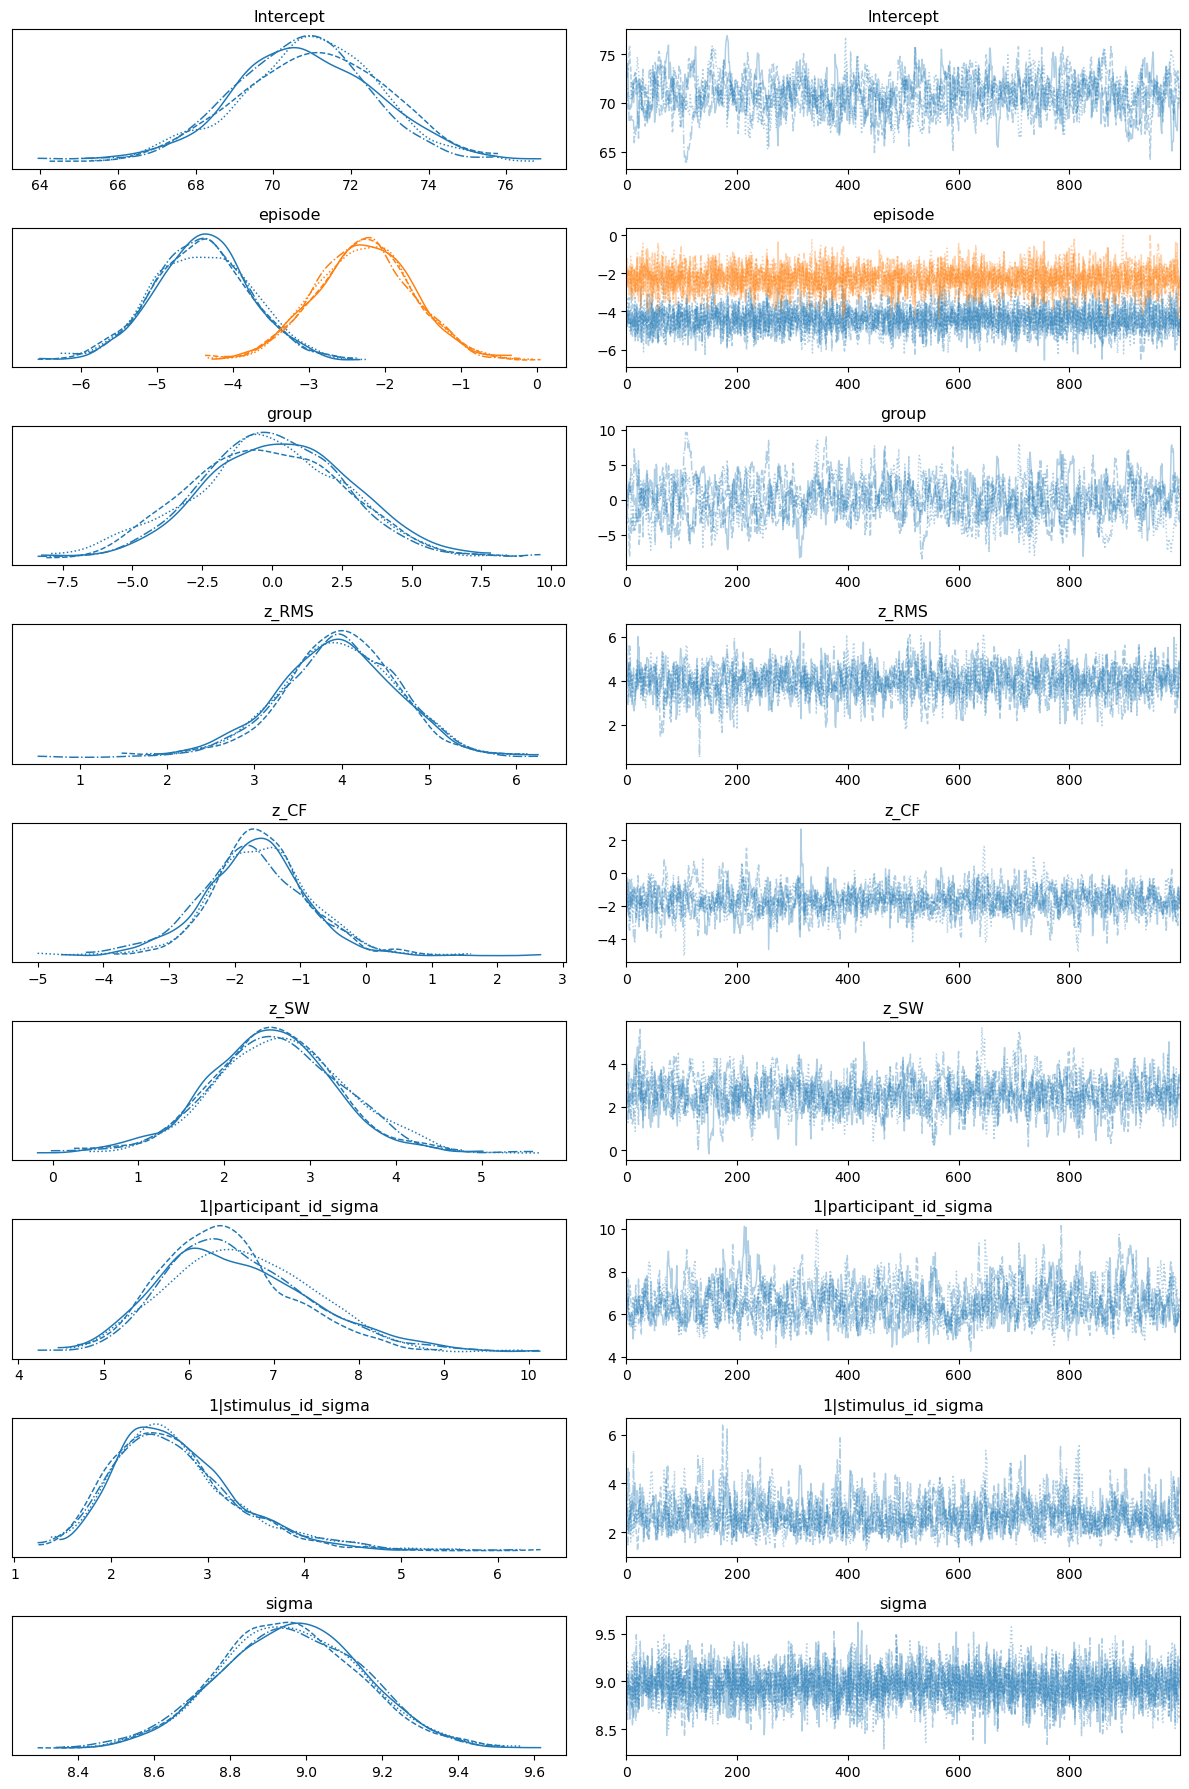

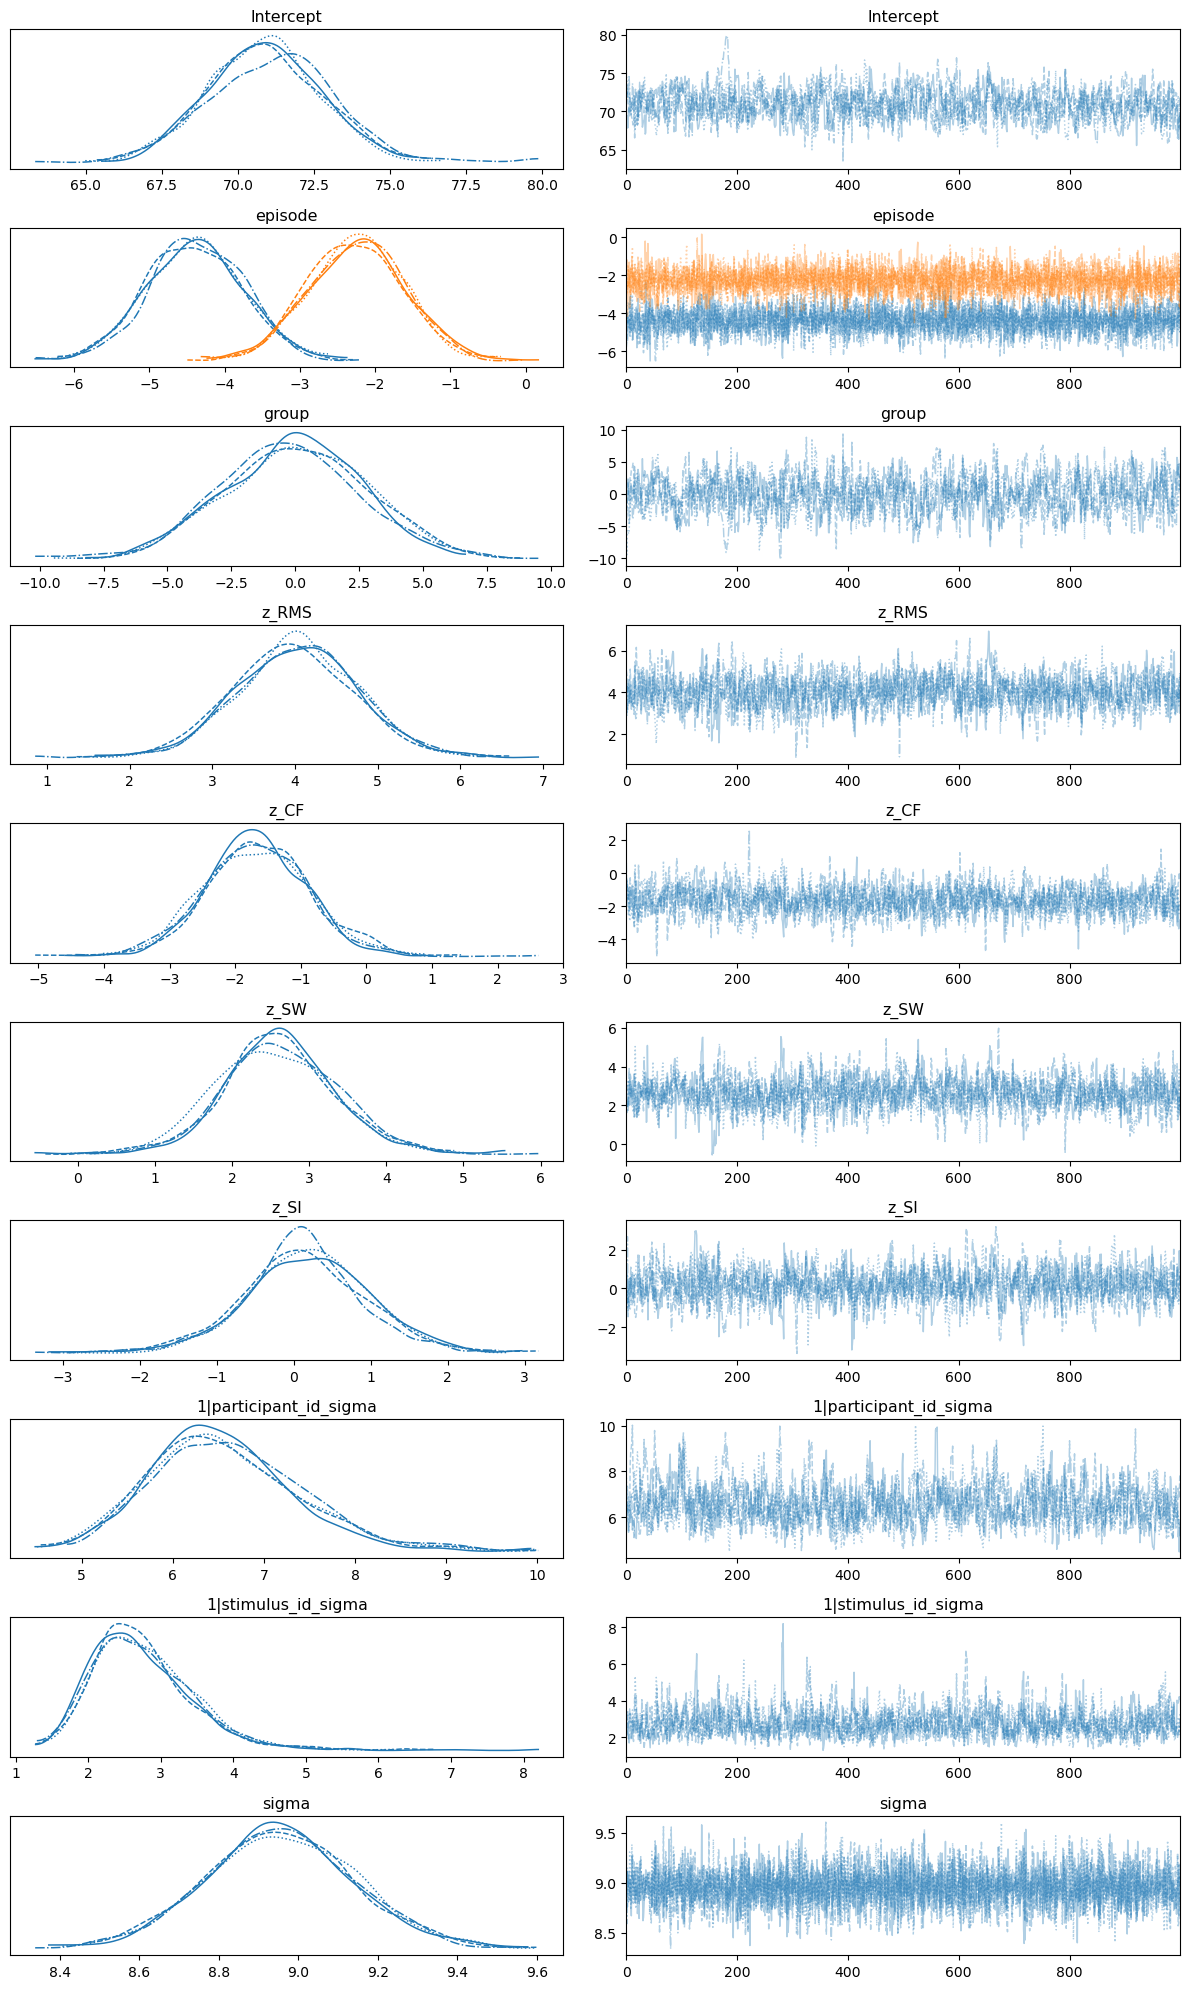

In [14]:
convergence_diagnostics = pd.DataFrame([intercept_diag, primary_diag, sensitivity_diag])
runtime_summary = pd.DataFrame([
    {"model": "intercept_only", "formula": INTERCEPT_ONLY_FORMULA, "runtime_seconds": intercept_runtime, **SAMPLING_CONFIG},
    {"model": "primary_feature", "formula": PRIMARY_FORMULA, "runtime_seconds": primary_runtime, **SAMPLING_CONFIG},
    {"model": "si_sensitivity", "formula": SENSITIVITY_FORMULA, "runtime_seconds": sensitivity_runtime, **SAMPLING_CONFIG},
])
display(runtime_summary)
display(convergence_diagnostics)

az.plot_trace(primary_idata, var_names=["Intercept", "episode", "group", "z_RMS", "z_CF", "z_SW", "1|participant_id_sigma", "1|stimulus_id_sigma", "sigma"], compact=True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "primary_feature_selected_trace.png", dpi=150, bbox_inches="tight")
plt.show()
az.plot_trace(sensitivity_idata, var_names=["Intercept", "episode", "group", "z_RMS", "z_CF", "z_SW", "z_SI", "1|participant_id_sigma", "1|stimulus_id_sigma", "sigma"], compact=True)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "si_sensitivity_selected_trace.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Posterior Predictive Checks

In [15]:
def build_mu_for_rows(idata, rows, include_participant=True):
    intercept = draw_values(idata, "Intercept")
    n = intercept.shape[0]
    mu = np.repeat(intercept[:, None], len(rows), axis=1)
    for j, row in enumerate(rows.itertuples(index=False)):
        mu[:, j] += coef_draws(idata, "episode", getattr(row, "episode"), n)
        mu[:, j] += coef_draws(idata, "group", getattr(row, "group"), n)
        for f in SENSITIVITY_FEATURES:
            if f in idata.posterior:
                mu[:, j] += draw_values(idata, f) * float(getattr(row, f))
        mu[:, j] += coef_draws(idata, "1|stimulus_id", getattr(row, "stimulus_id"), n)
        if include_participant:
            mu[:, j] += coef_draws(idata, "1|participant_id", getattr(row, "participant_id"), n)
    return mu

posterior_mu_observed = build_mu_for_rows(primary_idata, feature_df[["participant_id", "group", "stimulus_id", "episode", *SENSITIVITY_FEATURES]], True)
sigma_draws = draw_values(primary_idata, "sigma")
posterior_predictive = rng.normal(posterior_mu_observed, sigma_draws[:, None])
ppc_summary = pd.DataFrame([
    {"metric": "observed_mean", "value": feature_df["rating"].mean()},
    {"metric": "posterior_predictive_mean", "value": posterior_predictive.mean()},
    {"metric": "observed_sd", "value": feature_df["rating"].std(ddof=1)},
    {"metric": "posterior_predictive_sd", "value": posterior_predictive.std(ddof=1)},
    {"metric": "ppc_below_0", "value": float((posterior_predictive < 0).mean())},
    {"metric": "ppc_above_100", "value": float((posterior_predictive > 100).mean())},
    {"metric": "ppc_outside_0_100", "value": float(((posterior_predictive < 0) | (posterior_predictive > 100)).mean())},
])
ppc_group_rows = []
for factor in ["episode", "group", "stimulus_id"]:
    for level in feature_df[factor].astype(str).unique():
        mask = feature_df[factor].astype(str).to_numpy() == level
        means = posterior_predictive[:, mask].mean(axis=1)
        lo, hi = hdi_bounds(means)
        ppc_group_rows.append({"factor": factor, "level": level, "observed_mean": feature_df.loc[mask, "rating"].mean(), "posterior_predictive_mean": means.mean(), "hdi_3%": lo, "hdi_97%": hi, "absolute_error": abs(means.mean() - feature_df.loc[mask, "rating"].mean())})
ppc_group_summary = pd.DataFrame(ppc_group_rows)
display(ppc_summary)
display(ppc_group_summary.head(30))

,metric,value
0,observed_mean,68.651528
1,posterior_predictive_mean,68.660555
2,observed_sd,12.100056
3,posterior_predictive_sd,12.152221
4,ppc_below_0,0.000000
5,ppc_above_100,0.004312
6,ppc_outside_0_100,0.004312


,factor,level,observed_mean,posterior_predictive_mean,hdi_3%,hdi_97%,absolute_error
0,episode,EDR-1,70.871066,70.893613,69.680566,72.068380,0.022547
1,episode,EDR-2,66.477854,66.479120,65.315049,67.651149,0.001266
2,episode,FM-1,68.605665,68.608932,67.401924,69.788575,0.003266
3,group,group_01,69.133597,69.145937,68.154303,70.128972,0.012340
4,group,group_02,68.169460,68.175173,67.241436,69.154930,0.005714
5,stimulus_id,lead_me_mcg_pro2,76.131869,76.218079,73.289534,79.227359,0.086210
6,stimulus_id,lead_me_pxl_l4,71.624681,71.709812,68.724379,74.702886,0.085131
7,stimulus_id,lead_me_du_d,75.180144,75.145459,72.329072,78.098411,0.034684
8,stimulus_id,lead_me_du_e,60.462374,60.670249,57.613888,63.547623,0.207875
9,stimulus_id,lead_me_pxl_l1,67.338481,67.094584,64.370892,70.291015,0.243898


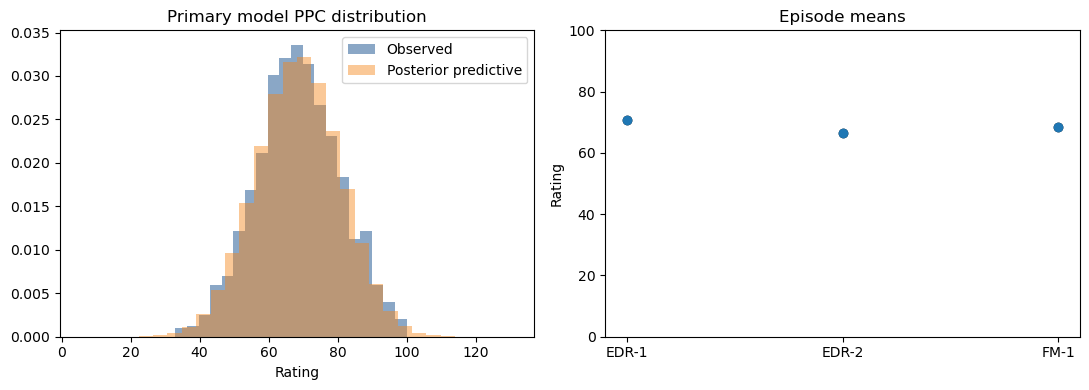

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(feature_df["rating"], bins=20, density=True, alpha=0.65, color="#4C78A8", label="Observed")
axes[0].hist(posterior_predictive.reshape(-1), bins=30, density=True, alpha=0.45, color="#F58518", label="Posterior predictive")
axes[0].set_title("Primary model PPC distribution")
axes[0].set_xlabel("Rating")
axes[0].legend()
ep = ppc_group_summary.loc[ppc_group_summary["factor"] == "episode"]
axes[1].errorbar(ep["level"], ep["posterior_predictive_mean"], yerr=[ep["posterior_predictive_mean"]-ep["hdi_3%"], ep["hdi_97%"]-ep["posterior_predictive_mean"]], fmt="o")
axes[1].scatter(ep["level"], ep["observed_mean"], color="black")
axes[1].set_title("Episode means")
axes[1].set_ylabel("Rating")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "primary_feature_posterior_predictive_checks.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Primary vs SI Sensitivity Model Comparison

In [17]:
loo_rows = []
try:
    primary_loo = az.loo(primary_idata)
    sensitivity_loo = az.loo(sensitivity_idata)
    loo_compare = az.compare({"primary_feature": primary_idata, "si_sensitivity": sensitivity_idata}, ic="loo").reset_index(names="model")
    loo_rows.append({"model": "primary_feature", "elpd_loo": float(primary_loo.elpd_loo), "se": float(primary_loo.se), "p_loo": float(primary_loo.p_loo), "pareto_k_gt_0_7": int((primary_loo.pareto_k > 0.7).sum())})
    loo_rows.append({"model": "si_sensitivity", "elpd_loo": float(sensitivity_loo.elpd_loo), "se": float(sensitivity_loo.se), "p_loo": float(sensitivity_loo.p_loo), "pareto_k_gt_0_7": int((sensitivity_loo.pareto_k > 0.7).sum())})
    loo_summary = pd.DataFrame(loo_rows)
except Exception as exc:
    loo_compare = pd.DataFrame([{"model": "comparison_failed", "error": str(exc)}])
    loo_summary = pd.DataFrame([{"model": "comparison_failed", "error": str(exc)}])
display(loo_summary)
display(loo_compare)

,model,elpd_loo,se,p_loo,pareto_k_gt_0_7
0,primary_feature,-4362.066059,24.195508,55.40298,0
1,si_sensitivity,-4362.391481,24.242955,55.87217,0


,model,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
0,primary_feature,0,-4362.066059,55.40298,0.000000,1.000000e+00,24.195508,0.000000,False,log
1,si_sensitivity,1,-4362.391481,55.87217,0.325422,1.665335e-16,24.242955,0.233083,False,log


## 12. Posterior Expected Ratings and Preferred-Mix Probabilities

In [18]:
prediction_grid = stimuli[["group", "song_id", "song_title", "mix_id", "stimulus_id", "original_mix_name", *SENSITIVITY_FEATURES]].merge(pd.DataFrame({"episode": EPISODE_LEVELS}), how="cross").sort_values(["song_id", "episode", "stimulus_id"]).reset_index(drop=True)
mu_grid = build_mu_for_rows(primary_idata, prediction_grid[["group", "stimulus_id", "episode", *SENSITIVITY_FEATURES]], include_participant=False)
expected_rows = []
for i, row in prediction_grid.iterrows():
    draws = mu_grid[:, i]
    lo, hi = hdi_bounds(draws)
    expected_rows.append({"song_id": row["song_id"], "song_title": row["song_title"], "group": row["group"], "episode": row["episode"], "stimulus_id": row["stimulus_id"], "mix_id": row["mix_id"], "original_mix_name": row["original_mix_name"], "posterior_mean_expected_rating": float(draws.mean()), "hdi_3%": lo, "hdi_97%": hi})
posterior_expected_ratings = pd.DataFrame(expected_rows)

winner_rows, winner_validation_rows = [], []
for (song_id, episode), group_df in posterior_expected_ratings.groupby(["song_id", "episode"], sort=True):
    grid_idx = posterior_expected_ratings.index[(posterior_expected_ratings["song_id"] == song_id) & (posterior_expected_ratings["episode"] == episode)].to_numpy()
    grid_idx = posterior_expected_ratings.loc[grid_idx].sort_values("stimulus_id").index.to_numpy()
    group_df = posterior_expected_ratings.loc[grid_idx].reset_index(drop=True)
    draw_matrix = mu_grid[:, grid_idx]
    winners = np.isclose(draw_matrix, draw_matrix.max(axis=1, keepdims=True), rtol=0, atol=1e-12)
    credit = winners / winners.sum(axis=1, keepdims=True)
    probs = credit.mean(axis=0)
    draw_tie_probability = float((winners.sum(axis=1) > 1).mean())
    max_prob = probs.max()
    final_tie_mask = np.isclose(probs, max_prob, rtol=0, atol=1e-12)
    final_winner = int(np.where(final_tie_mask)[0][0])
    for pos, (_, row) in enumerate(group_df.iterrows()):
        winner_rows.append({**row.to_dict(), "posterior_probability_highest": float(probs[pos]), "draw_level_tie_probability": draw_tie_probability, "is_final_probability_tie": bool(final_tie_mask[pos] and final_tie_mask.sum() > 1), "is_final_predicted_winner": bool(pos == final_winner), "winner_rule": "largest posterior_probability_highest; exact probability ties resolved by stimulus_id sort order"})
    winner_validation_rows.append({"song_id": song_id, "episode": episode, "n_candidates": len(group_df), "probability_sum": float(probs.sum()), "probabilities_between_0_and_1": bool(((probs >= 0) & (probs <= 1)).all()), "n_final_winners": 1, "draw_level_tie_probability": draw_tie_probability, "final_probability_tie": bool(final_tie_mask.sum() > 1)})
posterior_highest_rated_mixes = pd.DataFrame(winner_rows)
posterior_winner_validation = pd.DataFrame(winner_validation_rows)
winner_checks_passed = ((posterior_winner_validation["n_candidates"] == 5).all() and posterior_winner_validation["probabilities_between_0_and_1"].all() and np.allclose(posterior_winner_validation["probability_sum"], 1.0, atol=1e-10) and (posterior_highest_rated_mixes.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum() == 1).all())
if not winner_checks_passed:
    raise AssertionError("Posterior winner validation failed.")
display(posterior_highest_rated_mixes)
display(posterior_winner_validation)

,song_id,song_title,group,episode,stimulus_id,mix_id,original_mix_name,posterior_mean_expected_rating,hdi_3%,hdi_97%,posterior_probability_highest,draw_level_tie_probability,is_final_probability_tie,is_final_predicted_winner,winner_rule
0,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,65.010262,61.248221,68.254181,0.00000,0.0,False,False,largest posterior_probability_highest; exact p...
1,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,74.621050,71.316933,78.203092,0.37600,0.0,False,False,largest posterior_probability_highest; exact p...
2,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,70.613050,67.081609,74.071328,0.00025,0.0,False,False,largest posterior_probability_highest; exact p...
3,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,75.090215,71.568627,78.657821,0.62375,0.0,False,True,largest posterior_probability_highest; exact p...
4,id_like_to_know,I'd Like To Know,group_01,EDR-1,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,66.324425,62.876338,69.880220,0.00000,0.0,False,False,largest posterior_probability_highest; exact p...
5,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s1,mix_9ffcd672af17,PXL-S1,60.600740,57.072348,64.018571,0.00000,0.0,False,False,largest posterior_probability_highest; exact p...
6,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s2,mix_6f8b655d7999,PXL-S2,70.211528,66.694659,73.659726,0.37600,0.0,False,False,largest posterior_probability_highest; exact p...
7,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s3,mix_65f41f41d3ab,PXL-S3,66.203527,62.731675,69.819815,0.00025,0.0,False,False,largest posterior_probability_highest; exact p...
8,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s5,mix_82d60d7c7fc5,PXL-S5,70.680693,67.343108,74.436180,0.62375,0.0,False,True,largest posterior_probability_highest; exact p...
9,id_like_to_know,I'd Like To Know,group_01,EDR-2,id_like_to_know_pxl_s7,mix_b393d3919c78,PXL-S7,61.914903,58.441397,65.539282,0.00000,0.0,False,False,largest posterior_probability_highest; exact p...


,song_id,episode,n_candidates,probability_sum,probabilities_between_0_and_1,n_final_winners,draw_level_tie_probability,final_probability_tie
0,id_like_to_know,EDR-1,5,1.0,True,1,0.0,False
1,id_like_to_know,EDR-2,5,1.0,True,1,0.0,False
2,id_like_to_know,FM-1,5,1.0,True,1,0.0,False
3,in_the_meantime,EDR-1,5,1.0,True,1,0.0,False
4,in_the_meantime,EDR-2,5,1.0,True,1,0.0,False
5,in_the_meantime,FM-1,5,1.0,True,1,0.0,False
6,lead_me,EDR-1,5,1.0,True,1,0.0,False
7,lead_me,EDR-2,5,1.0,True,1,0.0,False
8,lead_me,FM-1,5,1.0,True,1,0.0,False
9,pouring_room,EDR-1,5,1.0,True,1,0.0,False


## 13. Conceptual Comparison with the Stimulus Baseline

The stimulus model, `rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)`, captures unexplained stimulus identity variation with partial pooling. The feature model, `rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)`, additionally estimates interpretable acoustic associations while retaining a stimulus random intercept for residual between-stimulus differences.

Both models use participant and stimulus partial pooling. Neither model contains context interactions. Both are population-level statistical baselines for later LLM comparison. Predictive scores from this feature-driven synthetic dataset should not be directly compared with scores from the separate Phase 3B.1 stimulus-driven dataset as evidence that one empirical model is superior.

In [19]:
stimulus_model_reference = pd.read_csv(STIMULUS_MODEL_SUMMARY_PATH) if STIMULUS_MODEL_SUMMARY_PATH.exists() else pd.DataFrame()
methodological_comparison = pd.DataFrame([
    {"model": "stimulus_baseline", "formula": "rating ~ episode + group + (1 | participant_id) + (1 | stimulus_id)", "role": "Captures participant variation and unexplained stimulus identity variation."},
    {"model": "feature_baseline", "formula": PRIMARY_FORMULA, "role": "Adds standardised acoustic associations while retaining residual stimulus partial pooling."},
])
display(methodological_comparison)
display(stimulus_model_reference.head())

,model,formula,role
0,stimulus_baseline,rating ~ episode + group + (1 | participant_id...,Captures participant variation and unexplained...
1,feature_baseline,rating ~ episode + group + z_RMS + z_CF + z_SW...,Adds standardised acoustic associations while ...


,item,value
0,notebook,statistical-baseline/notebooks/_02_categorical...
1,intercept_only_formula,rating ~ 1 + (1 | participant_id) + (1 | stimu...
2,full_model_formula,rating ~ episode + group + (1 | participant_id...
3,sampling_config,"{""draws"": 1000, ""tune"": 1000, ""chains"": 4, ""co..."
4,intercept_runtime_seconds,11.01500939996913


## 14. Recommended Feature-Based Baseline for Real Data

Unless future real-data diagnostics reveal a genuine problem, the primary real-data feature model should remain:

`rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)`

The SI model remains a sensitivity analysis only:

`rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)`

## 15. Export Feature Model Outputs

In [20]:
execution_summary = pd.DataFrame([
    {"item": "notebook", "value": "statistical-baseline/notebooks/_04_feature_based_model.ipynb"},
    {"item": "feature_driven_dataset_shape", "value": str(feature_df.shape)},
    {"item": "generating_coefficients", "value": json.dumps(FEATURE_EFFECTS_PRIMARY)},
    {"item": "clipped_rating_count", "value": clipped_count},
    {"item": "sampling_config", "value": json.dumps(SAMPLING_CONFIG)},
    {"item": "primary_formula", "value": PRIMARY_FORMULA},
    {"item": "sensitivity_formula", "value": SENSITIVITY_FORMULA},
    {"item": "ppc_outside_0_100", "value": float(ppc_summary.loc[ppc_summary["metric"] == "ppc_outside_0_100", "value"].iloc[0])},
    {"item": "winner_validation_passed", "value": winner_checks_passed},
])
exports = {
    "synthetic_generating_parameters": OUTPUT_DIR / "feature_synthetic_generating_parameters.json",
    "feature_driven_dataset_summary": OUTPUT_DIR / "feature_driven_dataset_summary.csv",
    "dataset_validation": OUTPUT_DIR / "feature_driven_dataset_validation.csv",
    "fixed_effect_primary_summary": OUTPUT_DIR / "fixed_effect_primary_summary.csv",
    "fixed_effect_sensitivity_summary": OUTPUT_DIR / "fixed_effect_sensitivity_summary.csv",
    "primary_sensitivity_loo_summary": OUTPUT_DIR / "primary_sensitivity_loo_summary.csv",
    "primary_sensitivity_loo_compare": OUTPUT_DIR / "primary_sensitivity_loo_compare.csv",
    "coefficient_recovery": OUTPUT_DIR / "coefficient_recovery.csv",
    "variance_component_recovery": OUTPUT_DIR / "variance_component_recovery.csv",
    "icc_recovery_summary": OUTPUT_DIR / "icc_recovery_summary.csv",
    "convergence_diagnostics": OUTPUT_DIR / "convergence_diagnostics.csv",
    "runtime_summary": OUTPUT_DIR / "runtime_execution_summary.csv",
    "netcdf_export_status": OUTPUT_DIR / "netcdf_export_status.csv",
    "posterior_predictive_summary": OUTPUT_DIR / "posterior_predictive_summary.csv",
    "posterior_predictive_group_summary": OUTPUT_DIR / "posterior_predictive_group_summary.csv",
    "posterior_expected_ratings": OUTPUT_DIR / "posterior_expected_ratings.csv",
    "posterior_highest_rated_mixes": OUTPUT_DIR / "predicted_highest_rated_mixes.csv",
    "posterior_winner_validation": OUTPUT_DIR / "posterior_winner_validation.csv",
    "methodological_comparison": OUTPUT_DIR / "methodological_comparison_with_stimulus_baseline.csv",
    "execution_summary": OUTPUT_DIR / "execution_summary.csv",
    "intercept_idata": OUTPUT_DIR / "intercept_only_feature_model_idata.nc",
    "primary_idata": OUTPUT_DIR / "primary_feature_model_idata.nc",
    "sensitivity_idata": OUTPUT_DIR / "si_sensitivity_feature_model_idata.nc",
}
with exports["synthetic_generating_parameters"].open("w", encoding="utf-8") as handle:
    json.dump(generating_parameters, handle, indent=2)
feature_dataset_summary.to_csv(exports["feature_driven_dataset_summary"], index=False)
dataset_validation.to_csv(exports["dataset_validation"], index=False)
primary_fixed_summary.to_csv(exports["fixed_effect_primary_summary"], index=False)
sensitivity_fixed_summary.to_csv(exports["fixed_effect_sensitivity_summary"], index=False)
loo_summary.to_csv(exports["primary_sensitivity_loo_summary"], index=False)
loo_compare.to_csv(exports["primary_sensitivity_loo_compare"], index=False)
coefficient_recovery_table.to_csv(exports["coefficient_recovery"], index=False)
variance_component_recovery.to_csv(exports["variance_component_recovery"], index=False)
icc_recovery_summary.to_csv(exports["icc_recovery_summary"], index=False)
convergence_diagnostics.to_csv(exports["convergence_diagnostics"], index=False)
runtime_summary.to_csv(exports["runtime_summary"], index=False)
pd.DataFrame(NETCDF_EXPORT_STATUS).to_csv(exports["netcdf_export_status"], index=False)
ppc_summary.to_csv(exports["posterior_predictive_summary"], index=False)
ppc_group_summary.to_csv(exports["posterior_predictive_group_summary"], index=False)
posterior_expected_ratings.to_csv(exports["posterior_expected_ratings"], index=False)
posterior_highest_rated_mixes.to_csv(exports["posterior_highest_rated_mixes"], index=False)
posterior_winner_validation.to_csv(exports["posterior_winner_validation"], index=False)
methodological_comparison.to_csv(exports["methodological_comparison"], index=False)
execution_summary.to_csv(exports["execution_summary"], index=False)
export_summary = pd.DataFrame([{"artifact": k, "path": str(v.relative_to(REPO_ROOT)), "exists": v.exists()} for k, v in exports.items()])
export_summary

,artifact,path,exists
0,synthetic_generating_parameters,statistical-baseline\outputs\feature_model\fea...,True
1,feature_driven_dataset_summary,statistical-baseline\outputs\feature_model\fea...,True
2,dataset_validation,statistical-baseline\outputs\feature_model\fea...,True
3,fixed_effect_primary_summary,statistical-baseline\outputs\feature_model\fix...,True
4,fixed_effect_sensitivity_summary,statistical-baseline\outputs\feature_model\fix...,True
5,primary_sensitivity_loo_summary,statistical-baseline\outputs\feature_model\pri...,True
6,primary_sensitivity_loo_compare,statistical-baseline\outputs\feature_model\pri...,True
7,coefficient_recovery,statistical-baseline\outputs\feature_model\coe...,True
8,variance_component_recovery,statistical-baseline\outputs\feature_model\var...,True
9,icc_recovery_summary,statistical-baseline\outputs\feature_model\icc...,True


## 16. Limitations and Next Steps

The feature-driven ratings are synthetic and use hypothetical acoustic coefficients. Acoustic-feature information exists at only 20 unique stimulus levels, even though there are 1,200 repeated rating rows. Group remains confounded with assigned song set. SI remains sensitivity-only because repository evidence treats it as QC-related metadata, and Bark features are excluded from the primary model because no globally valid final-20 scalar/PCA representation is available.

The primary model is additive and does not estimate context-specific acoustic effects. Real participant data will require fresh convergence diagnostics, posterior predictive checks, Gaussian boundary checks, and careful interpretation before any dissertation claims are made.

In [21]:
completion_report = {
    "notebook": "statistical-baseline/notebooks/_04_feature_based_model.ipynb",
    "feature_driven_dataset_shape": feature_df.shape,
    "generating_coefficients": FEATURE_EFFECTS_PRIMARY,
    "clipped_rating_count": clipped_count,
    "formulas_fitted": [INTERCEPT_ONLY_FORMULA, PRIMARY_FORMULA, SENSITIVITY_FORMULA],
    "runtime_per_model_seconds": runtime_summary[["model", "runtime_seconds"]].to_dict(orient="records"),
    "sampling_configuration": SAMPLING_CONFIG,
    "diagnostics": convergence_diagnostics.to_dict(orient="records"),
    "true_vs_recovered_feature_coefficients": coefficient_recovery_table.to_dict(orient="records"),
    "true_vs_recovered_iccs": icc_recovery_summary[icc_recovery_summary["model"].eq("primary_feature")].to_dict(orient="records"),
    "ppc_outside_range_rate": float(ppc_summary.loc[ppc_summary["metric"] == "ppc_outside_0_100", "value"].iloc[0]),
    "loo_result": loo_summary.to_dict(orient="records"),
    "posterior_winner_validation_passed": winner_checks_passed,
    "final_primary_formula": PRIMARY_FORMULA,
    "exported_files": export_summary.loc[export_summary["exists"], "path"].tolist(),
    "unresolved_concerns": "No blocking concerns. Main caution is the small number of feature-level observations and group/song-set confounding.",
}
completion_report

{'notebook': 'statistical-baseline/notebooks/_04_feature_based_model.ipynb',
 'feature_driven_dataset_shape': (1200, 19),
 'generating_coefficients': {'z_RMS': 2.6, 'z_CF': -2.1, 'z_SW': 2.3},
 'clipped_rating_count': 5,
 'formulas_fitted': ['rating ~ 1 + (1 | participant_id) + (1 | stimulus_id)',
  'rating ~ episode + group + z_RMS + z_CF + z_SW + (1 | participant_id) + (1 | stimulus_id)',
  'rating ~ episode + group + z_RMS + z_CF + z_SW + z_SI + (1 | participant_id) + (1 | stimulus_id)'],
 'runtime_per_model_seconds': [{'model': 'intercept_only',
   'runtime_seconds': 10.02857799991034},
  {'model': 'primary_feature', 'runtime_seconds': 8.64018869982101},
  {'model': 'si_sensitivity', 'runtime_seconds': 8.988711199956015}],
 'sampling_configuration': {'draws': 1000,
  'tune': 1000,
  'chains': 4,
  'cores': 1,
  'target_accept': 0.95,
  'random_seed': 44,
  'inference_method': 'nutpie'},
 'diagnostics': [{'model': 'intercept_only',
   'divergences': 0,
   'max_rhat': 1.02,
   'min_b